In [6]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import keras
import scipy
from sklearn.model_selection import train_test_split
from tqdm import trange
import sys
import time

# import  settings

sys.path.append('..')

import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)
import plot_settings
plot_settings.apply()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pybamm/solvers/base_solver.py:1008: SolverWarning: While solving Doyle-Fuller-Newman model extrapolation occurred for ["Interpolant 'interpolating_function' upper bound"]
  self.check_extrapolation(solution, model.events)


2734.1426445526936


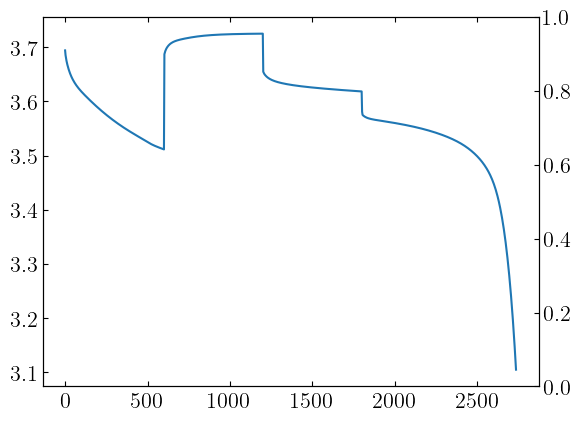

In [7]:
tt,vv,ii = sim_PyBaMM.get_volt_variable(1)

f, ax = plt.subplots()
axt = ax.twinx()
ax.plot(tt,vv)


print(tt[-1])

In [8]:
def gen_data(I, save = True):
    t,u = sim_PyBaMM.get_voltage(I)
    i = np.ones_like(t) * I
    data = np.array([i,u]).T

    return data,t[-1]

In [9]:
i = np.arange(1, 41)
D = np.zeros((len(i),1000,2))
ts = []
for Is,n in zip(i,trange(len(i))):
    I = np.round(Is / 20,2)

    ts.append(gen_data(I)[1])


 98%|█████████▊| 39/40 [00:18<00:00,  2.14it/s]


In [10]:
def f_It(I,k,n):
    return k * I**(-n)

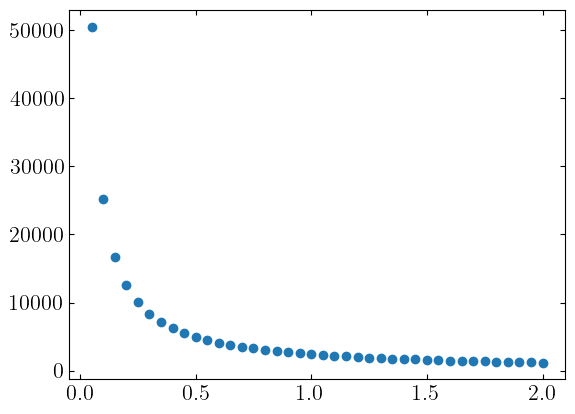

In [11]:
plt.scatter(i/20,ts)


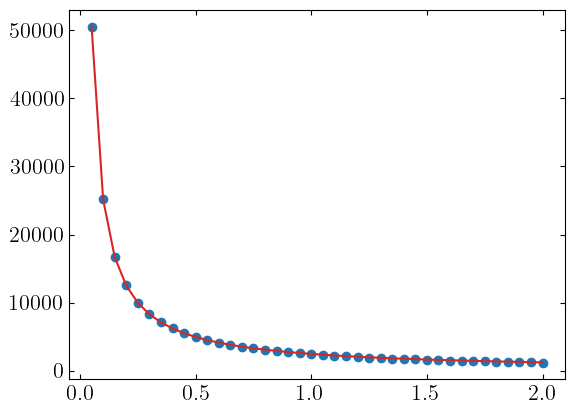

In [12]:
def f_It(I,k,n):
    return k * I**(-n)
i = np.arange(1, 41)
popt, pcov = scipy.optimize.curve_fit(f_It, i/20, ts)
plt.scatter(i/20,ts)
plt.plot(i/20,f_It(i/20,*popt),color='tab:red')

In [13]:
i = np.arange(1, 41)
D = np.zeros((len(i),1000,2))
for Is,n in zip(i,trange(len(i))):
    I = np.round(Is / 20,2)

    D[n,...] = gen_data(I)[0]

 98%|█████████▊| 39/40 [00:17<00:00,  2.21it/s]


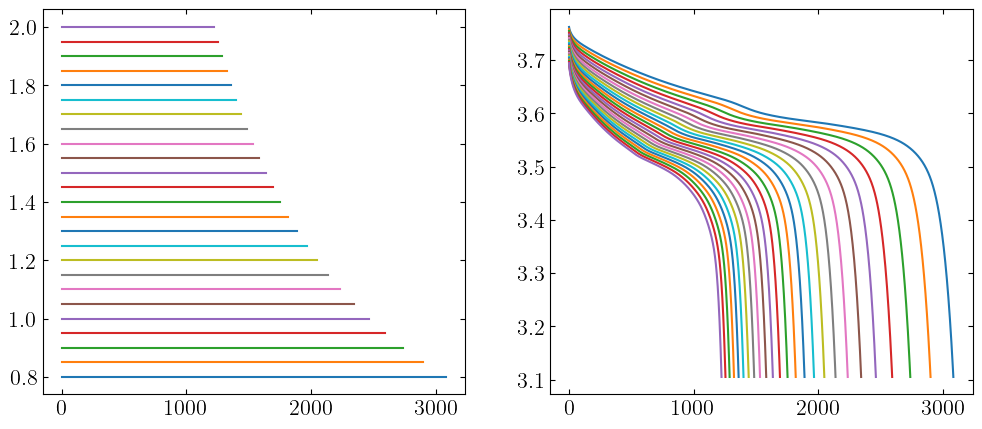

In [14]:
i = np.arange(1, 41)
f,ax = plt.subplots(1,2,figsize=(12,5))
for N in range(15,len(i)):
    ax[0].plot(np.linspace(0,f_It(i[N]/20,*popt),len(D[N,:,0])),D[N,:,0])
    ax[1].plot(np.linspace(0,f_It(i[N]/20,*popt),len(D[N,:,0])),D[N,:,1])

In [15]:
X_train, X_, y_train, y_ = train_test_split(D[:,:,:1], D[:,:,1:], test_size=0.3, random_state=42)

X_train = X_train[:,0,:]
X_ = X_[:,0,:]

print(X_train.shape, y_train.shape)
X_valid, X_test, y_valid, y_test = train_test_split(X_, y_, test_size=0.3, random_state=42)





print(X_train.shape, y_train.shape, X_valid.shape, y_valid.shape, X_test.shape, y_test.shape)

(28, 1) (28, 1000, 1)
(28, 1) (28, 1000, 1) (8, 1) (8, 1000, 1) (4, 1) (4, 1000, 1)


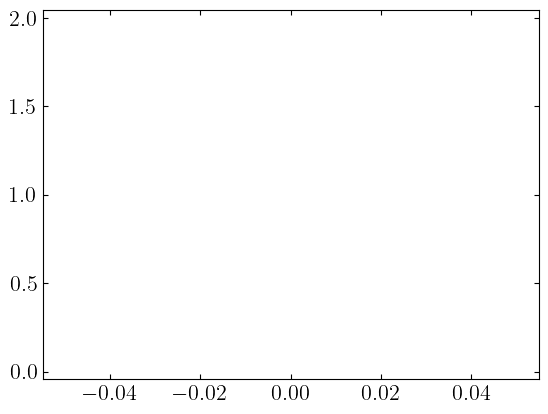

In [16]:
for i in range(len(X_train)):
    plt.plot(X_train[i])
plt.show()

In [17]:
model = keras.Sequential([
    keras.layers.Input((1,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1000)   # outputs the whole sequence
])


model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

In [18]:
epochs = 500     ## Number of epoch to run
batch_size = 80  ## Number of samples per gradient update

es = keras.callbacks.EarlyStopping('val_loss', patience=50, restore_best_weights = True)

# Train the model
history = model.fit(
  X_train, y_train,
  epochs=epochs,
  verbose = 1,
  validation_data=(X_valid, y_valid),
  callbacks=[es]
)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 965ms/step - loss: 12.9118 - mae: 3.5916 - val_loss: 12.8427 - val_mae: 3.5821
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 12.8218 - mae: 3.5789 - val_loss: 12.7438 - val_mae: 3.5681
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 12.7178 - mae: 3.5642 - val_loss: 12.6104 - val_mae: 3.5491
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 12.5777 - mae: 3.5442 - val_loss: 12.4307 - val_mae: 3.5234
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 12.3891 - mae: 3.5170 - val_loss: 12.1954 - val_mae: 3.4893
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 12.1424 - mae: 3.4811 - val_loss: 11.8947 - val_mae: 3.4452
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.8278 - mae: 3.4345 - val_loss: 11.5197 - val_mae: 3.3891
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 11.4362 - mae: 3.3754 - val_loss: 11.0610 - val_mae: 3.3188
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - los

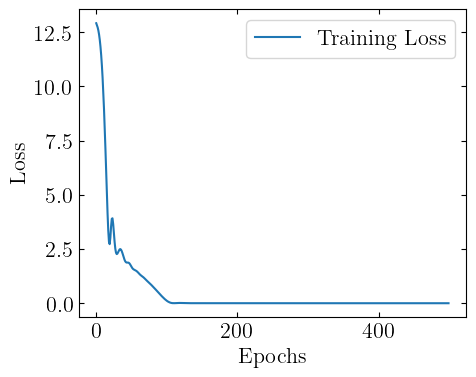

In [19]:
train_loss = history.history['loss']
#valid_loss = history.history['val_loss']

fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4))
ax1.plot(train_loss, label='Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()


In [22]:
I_test = np.array([3.18])
for i in trange(5):
    #t_t, u_t = sim_PyBaMM.get_voltage(0.7)
    pred = model.predict(I_test,verbose=0)


100%|██████████| 5/5 [00:00<00:00, 23.27it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


Text(0.5, 1.0, 'Voltage response for $I = 3.18$ A')

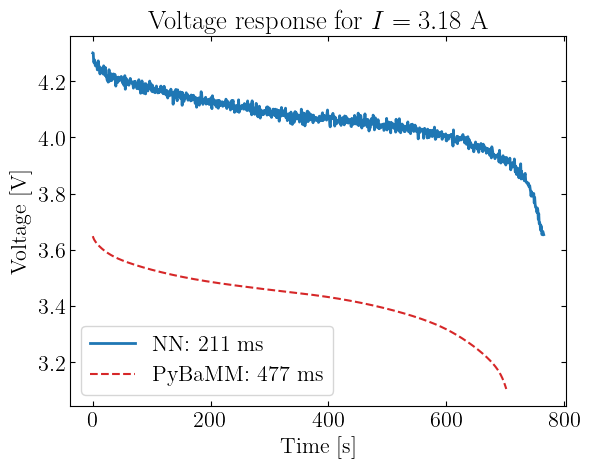

In [24]:
start_NN = time.perf_counter() * 1000
pred = model.predict(I_test)
end_NN = time.perf_counter() * 1000
diff_NN = end_NN - start_NN

start_pb = time.perf_counter() * 1000
t_t, u_t = sim_PyBaMM.get_voltage(I_test[0])
end_pb = time.perf_counter() * 1000
diff_pb = end_pb - start_pb

#f,ax = plt.subplots(1,2,figsize=(8,4))
plt.plot(np.linspace(0,f_It(I_test,*popt),1000),pred.ravel(),lw = 2, label = f'NN: {diff_NN:.0f} ms')
plt.plot(t_t,u_t,color='tab:red',ls = '--',label = f'PyBaMM: {diff_pb:.0f} ms')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.title(f'Voltage response for $I = {I_test[0]}$ A')
#plt.savefig(f'NNN_figs/NNN_PyBaMM_comparison_I_{I_test[0]}.pdf',dpi=300)
#ax[1].plot(np.linspace(0,f_It(I_test,*popt),1000),pred.ravel() - u_t)
